# Frozen AMP Discriminator Analysis

This notebook analyzes a **frozen discriminator** from an AMP checkpoint.

It will:
1. Load policy/discriminator/normalizer from a checkpoint folder.
2. Collect agent trajectories with environment/config wiring matching AMP training.
3. Score both agent trajectories and demo trajectories with the discriminator.
4. Build a confusion matrix (`demo=expert`, `agent=agent`) and key metrics.
5. Visualize random trajectory windows from TP/FN/TN/FP categories.

> Classification convention follows LSGAN training in `amp_training_lsgan.py`:
> - predict **expert** if discriminator logit `> threshold` (default `0.0`)
> - predict **agent** otherwise.

In [1]:
import copy
import math
import random
from pathlib import Path
from types import SimpleNamespace

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

from airhockey import AirHockeyEnv
import importlib
import scripts.smooth_policy.agent as agent_module

importlib.reload(agent_module)
Agent = agent_module.Agent

from scripts.smooth_policy.amp_history.amp_training.demo_loader_position_history import DemoLoaderPositionHistory
from scripts.smooth_policy.amp_history.amp_training.discriminator import Discriminator
from scripts.smooth_policy.amp_history.amp_training.feature_processing import (
    build_puck_discriminator_features_torch,
    normalize_action_history_batch,
    normalize_position_history_batch,
)
from scripts.smooth_policy.amp_history.amp_training.normalizer import Normalizer

plt.style.use("default")
np.set_printoptions(suppress=True, precision=4)
torch.set_printoptions(sci_mode=False, precision=4)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/air-hockey/daliu/air-hockey-rl/.venv/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Some air hockey components not installed. Does not work on Apple Silicon
Torch: 2.8.0+cu128
CUDA available: True


In [21]:
# -------------------------
# User configuration
# -------------------------

checkpoint_dir = Path(
    "runs/rma/test_ppo/no_task_reward/checkpoint_2020".strip()
)
# demo_data_path should follow the same format as AMP training args.
demo_data_path = Path(
    "/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/amp_data/amp_paddle_puck_dataset.pt"
)

# Rollout + scoring knobs
num_agent_episodes = 100
max_total_env_steps = None  # e.g., 3000 for a quick run
rollout_num_envs_override = None  # None -> use args.yaml num_envs

# Sample controls
max_demo_samples = None  # None -> use all demo samples before balancing
max_agent_samples = None  # None -> use all collected agent samples before balancing
balance_classes = True  # If True, use equal counts for demo(expert) and agent classes
score_batch_size = 4096
classification_threshold = 0.0
samples_per_category_plot = 20

# Device
device = "cuda:0" if torch.cuda.is_available() else "cpu"

print("checkpoint_dir:", checkpoint_dir)
print("demo_data_path:", demo_data_path)
print("device:", device)

checkpoint_dir: runs/rma/test_ppo/no_task_reward/checkpoint_2020
demo_data_path: /home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/amp_data/amp_paddle_puck_dataset.pt
device: cuda:0


In [ ]:
from pathlib import Path


def find_run_dir_from_checkpoint(checkpoint_dir: Path) -> Path:
    checkpoint_dir = checkpoint_dir.resolve()
    candidates = [checkpoint_dir] + list[Path](checkpoint_dir.parents)
    for c in candidates:
        print(c / "args.yaml", (c / "config.yaml"))
        if (c / "args.yaml").exists() and (c / "config.yaml").exists():
            return c
    raise FileNotFoundError(
        f"Could not find args.yaml + config.yaml by searching upward from {checkpoint_dir}"
    )


def load_yaml(path: Path):
    with open(path, "r") as f:
        return yaml.load(f, Loader=yaml.FullLoader)


def parse_discriminator_hidden_dims(hidden_sizes):
    hidden_dims = [int(size) for size in hidden_sizes]
    if len(hidden_dims) == 0:
        raise ValueError("disc_hidden_sizes must contain at least one layer size.")
    if any(size <= 0 for size in hidden_dims):
        raise ValueError(f"disc_hidden_sizes must be positive, got: {hidden_dims}")
    return hidden_dims


def augment_policy_observation(observation: torch.Tensor, last_action: torch.Tensor, use_last_action: bool):
    if not use_last_action:
        return observation
    return torch.cat([observation, last_action], dim=-1)


def extract_current_paddle_position(observation: torch.Tensor) -> torch.Tensor:
    obs_dim = observation.shape[-1]
    if obs_dim >= 30:
        return observation[:, 12:14]
    return observation[:, 0:2]


def extract_current_puck_position(observation: torch.Tensor) -> torch.Tensor:
    obs_dim = observation.shape[-1]
    if obs_dim >= 30:
        return observation[:, 27:29]
    if obs_dim >= 8:
        return observation[:, 4:6]
    if obs_dim >= 4:
        return observation[:, 2:4]
    raise ValueError(f"Observation dim {obs_dim} is too small to extract puck position.")


def make_env_factory(air_hockey_cfg: dict):
    def _thunk():
        env_cfg = copy.deepcopy(air_hockey_cfg)
        curr_seed = random.randint(0, int(1e8))
        env_cfg["seed"] = curr_seed
        if "simulator_params" in env_cfg and isinstance(env_cfg["simulator_params"], dict):
            env_cfg["simulator_params"]["seed"] = curr_seed
        return AirHockeyEnv(env_cfg)

    return _thunk


def build_vector_envs(air_hockey_cfg: dict, num_envs: int):
    env_fns = [make_env_factory(air_hockey_cfg) for _ in range(num_envs)]
    return gym.vector.AsyncVectorEnv(env_fns)

In [ ]:
# resolved = checkpoint_dir.resolve()
# for c in resolved.parents:
#     print(c)

run_dir = find_run_dir_from_checkpoint(checkpoint_dir)
args_path = run_dir / "args.yaml"
config_path = run_dir / "config.yaml"

args_dict = load_yaml(args_path)
config = load_yaml(config_path)
air_hockey_cfg = config["air_hockey"]

if not demo_data_path.exists():
    # Fallback to run arg path if user path is not valid.
    demo_data_path = Path(args_dict["demo_data_path"])

if not demo_data_path.is_absolute():
    # Resolve relative paths from workspace root assumption.
    demo_data_path = (Path.cwd() / demo_data_path).resolve()

if not demo_data_path.exists():
    raise FileNotFoundError(f"demo_data_path not found: {demo_data_path}")

num_envs = int(rollout_num_envs_override or args_dict["num_envs"])
use_last_action = bool(args_dict.get("use_last_action_in_policy_state", False))
use_action_disc = bool(args_dict.get("use_action_discriminator", False))
use_puck_disc = bool(args_dict.get("use_puck_discriminator", False))

print("run_dir:", run_dir)
print("args_path:", args_path)
print("config_path:", config_path)
print("num_envs for rollout:", num_envs)
print("use_last_action_in_policy_state:", use_last_action)
print("use_action_discriminator:", use_action_disc)
print("use_puck_discriminator:", use_puck_disc)
print("obs_type:", air_hockey_cfg.get("obs_type"))
print("task:", air_hockey_cfg.get("task"))

/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma/test_ppo/no_task_reward
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma/test_ppo
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy
/home/air-hockey/daliu/air-hockey-rl/scripts
/home/air-hockey/daliu/air-hockey-rl
/home/air-hockey/daliu
/home/air-hockey
/home
/
/home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma/test_ppo/no_task_reward/checkpoint_2020/args.yaml /home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma/test_ppo/no_task_re

FileNotFoundError: Could not find args.yaml + config.yaml by searching upward from /home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/runs/rma/test_ppo/no_task_reward/checkpoint_2020

In [ ]:
def resolve_existing_path(path_like: str | Path, base_dirs: list[Path]) -> Path:
    p = Path(path_like)
    if p.is_absolute() and p.exists():
        return p
    for base in base_dirs:
        candidate = (base / p).resolve()
        if candidate.exists():
            return candidate
    if p.exists():
        return p.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")


def build_agent_and_discriminator(
    checkpoint_dir: Path,
    run_dir: Path,
    args_dict: dict,
    air_hockey_cfg: dict,
    demo_data_path: Path,
    device: str,
):
    base_dirs = [Path.cwd(), run_dir, run_dir.parent, run_dir.parent.parent]

    envs = build_vector_envs(air_hockey_cfg, int(args_dict["num_envs"]))
    obs_dim = int(np.prod(envs.single_observation_space.shape))
    action_dim = int(np.prod(envs.single_action_space.shape))
    policy_obs_dim = obs_dim + action_dim if bool(args_dict.get("use_last_action_in_policy_state", False)) else obs_dim

    policy_env_view = SimpleNamespace(
        single_observation_space=gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(policy_obs_dim,),
            dtype=np.float32,
        ),
        single_action_space=envs.single_action_space,
    )

    if air_hockey_cfg.get("use_pid", False):
        action_scale = 1
    else:
        action_scale = float(args_dict["action_scale"])

    agent_hidden_size = int(args_dict["agent_hidden_size"])

    agent = Agent(
        policy_env_view,
        action_scale=action_scale,
        action_bias=0.0,
        hidden_size=agent_hidden_size,
    ).to(device)

    model_path = resolve_existing_path(checkpoint_dir / "model.pth", base_dirs)
    agent.load_state_dict(torch.load(model_path, map_location=device))
    agent.eval()

    demo_loader = DemoLoaderPositionHistory(
        str(demo_data_path),
        device=device,
        use_actions=bool(args_dict.get("use_action_discriminator", False)),
        use_puck=bool(args_dict.get("use_puck_discriminator", False)),
        puck_vertical_axis=int(args_dict.get("puck_vertical_axis", 0)),
        puck_downward_positive_direction=float(args_dict.get("puck_downward_positive_direction", 1.0)),
        puck_downward_speed_max=float(args_dict.get("puck_downward_speed_max", 0.75)),
        puck_speed_dt=float(args_dict.get("puck_speed_dt", 0.05)),
        puck_noise_std=float(args_dict.get("puck_noise_std", 0.03)),
        puck_vertical_pos_min=float(args_dict.get("puck_vertical_pos_min", -1.0)),
        puck_vertical_pos_max=float(args_dict.get("puck_vertical_pos_max", 1.0)),
    )

    disc_obs_dim = int(demo_loader.get_obs_dim())
    disc_hidden_sizes = parse_discriminator_hidden_dims(args_dict.get("disc_hidden_sizes", [64, 64]))

    discriminator = Discriminator(
        disc_obs_dim,
        hidden_dims=disc_hidden_sizes,
        activation="leaky_relu",
    ).to(device)

    discriminator_path = resolve_existing_path(checkpoint_dir / "discriminator.pth", base_dirs)
    discriminator.load_state_dict(torch.load(discriminator_path, map_location=device))
    discriminator.eval()

    amp_components_path = resolve_existing_path(checkpoint_dir / "amp_components.pth", base_dirs)
    amp_components = torch.load(amp_components_path, map_location=device)

    disc_normalizer = Normalizer(shape=(disc_obs_dim,), clip=10.0, device=device)
    disc_normalizer.load_state_dict(amp_components["normalizer"])

    return {
        "envs": envs,
        "agent": agent,
        "discriminator": discriminator,
        "disc_normalizer": disc_normalizer,
        "demo_loader": demo_loader,
        "obs_dim": obs_dim,
        "action_dim": action_dim,
        "policy_obs_dim": policy_obs_dim,
        "disc_obs_dim": disc_obs_dim,
        "action_scale": action_scale,
        "agent_hidden_size": agent_hidden_size,
    }


components = build_agent_and_discriminator(
    checkpoint_dir=checkpoint_dir,
    run_dir=run_dir,
    args_dict=args_dict,
    air_hockey_cfg=air_hockey_cfg,
    demo_data_path=demo_data_path,
    device=device,
)

print("Loaded components:")
for k in [
    "obs_dim",
    "action_dim",
    "policy_obs_dim",
    "disc_obs_dim",
    "action_scale",
    "agent_hidden_size",
]:
    print(f"  {k}: {components[k]}")

Loading demonstration position history data from: /home/air-hockey/daliu/air-hockey-rl/scripts/smooth_policy/amp_history/amp_training/amp_data/amp_paddle_puck_dataset.pt
✓ Loaded 19,972 demonstration observations
  Base observation shape: torch.Size([19972, 8])
  Observation dim used for discriminator: 8
  Dataset has actions: True, using actions: False
  Dataset has puck: True, using puck: False

  Demonstration data statistics:
    sample_bucketed_points: False
    use_puck: False
    obs_dim: 8
Loaded components:
  obs_dim: 30
  action_dim: 2
  policy_obs_dim: 30
  disc_obs_dim: 8
  action_scale: 1.0
  agent_hidden_size: 512


In [ ]:
def collect_agent_discriminator_samples(
    envs,
    agent,
    args_dict,
    target_completed_episodes: int,
    device: str,
    max_total_env_steps: int | None = None,
):
    history_len = 5
    action_history_len = history_len - 1

    use_last_action = bool(args_dict.get("use_last_action_in_policy_state", False))
    use_action_disc = bool(args_dict.get("use_action_discriminator", False))
    use_puck_disc = bool(args_dict.get("use_puck_discriminator", False))

    num_envs = envs.num_envs
    action_dim = int(np.prod(envs.single_action_space.shape))

    next_obs_np, _ = envs.reset(seed=int(args_dict.get("seed", 0)))
    next_obs = torch.tensor(next_obs_np, dtype=torch.float32, device=device)
    next_done = torch.zeros(num_envs, dtype=torch.bool, device=device)
    just_reset = torch.zeros(num_envs, dtype=torch.bool, device=device)

    last_action_for_policy = torch.zeros((num_envs, action_dim), dtype=torch.float32, device=device)

    position_history = torch.zeros((num_envs, history_len, 2), dtype=torch.float32, device=device)
    action_history = (
        torch.zeros((num_envs, action_history_len, 2), dtype=torch.float32, device=device)
        if use_action_disc
        else None
    )
    puck_position_history = (
        torch.zeros((num_envs, history_len, 2), dtype=torch.float32, device=device)
        if use_puck_disc
        else None
    )

    position_count = torch.zeros(num_envs, dtype=torch.long, device=device)
    action_count = torch.zeros(num_envs, dtype=torch.long, device=device) if use_action_disc else None
    puck_count = torch.zeros(num_envs, dtype=torch.long, device=device) if use_puck_disc else None

    env_episode_ids = torch.arange(num_envs, dtype=torch.long, device=device)
    next_episode_id = int(num_envs)
    step_in_episode = torch.zeros(num_envs, dtype=torch.long, device=device)

    completed_episodes = 0
    total_env_steps = 0
    records = []

    while completed_episodes < target_completed_episodes:
        with torch.no_grad():
            policy_obs = augment_policy_observation(next_obs, last_action_for_policy, use_last_action)
            action, _, _, _ = agent.get_action_and_value(policy_obs)

        next_obs_np, _, terminations, truncations, _ = envs.step(action.detach().cpu().numpy())
        done_np = np.logical_or(terminations, truncations)

        next_obs = torch.tensor(next_obs_np, dtype=torch.float32, device=device)
        next_done = torch.tensor(done_np, dtype=torch.bool, device=device)

        current_paddle_pos = extract_current_paddle_position(next_obs)
        current_puck_pos = extract_current_puck_position(next_obs) if use_puck_disc else None

        position_history = torch.roll(position_history, shifts=-1, dims=1)
        position_history[:, -1, :] = current_paddle_pos

        if use_action_disc:
            action_history = torch.roll(action_history, shifts=-1, dims=1)
            action_history[:, -1, :] = action

        if use_puck_disc:
            puck_position_history = torch.roll(puck_position_history, shifts=-1, dims=1)
            puck_position_history[:, -1, :] = current_puck_pos

        position_count = torch.clamp(position_count + 1, max=history_len)
        valid_transition = position_count >= history_len

        if use_action_disc:
            action_count = torch.clamp(action_count + 1, max=action_history_len)
            valid_transition = valid_transition & (action_count >= action_history_len)

        if use_puck_disc:
            puck_count = torch.clamp(puck_count + 1, max=history_len)
            valid_transition = valid_transition & (puck_count >= history_len)

        valid_transition[just_reset] = False

        normalized_position_history = position_history - position_history[:, :1, :]
        normalized_positions = normalized_position_history[:, 1:, :].reshape(num_envs, -1)
        disc_feature_parts = [normalized_positions]

        if use_action_disc:
            normalized_actions = normalize_action_history_batch(action_history)
            disc_feature_parts.append(normalized_actions)
        else:
            normalized_actions = None

        if use_puck_disc:
            puck_features = build_puck_discriminator_features_torch(
                puck_position_history,
                current_index=2,
                vertical_axis=int(args_dict.get("puck_vertical_axis", 0)),
                downward_positive_direction=float(args_dict.get("puck_downward_positive_direction", 1.0)),
                downward_speed_max=float(args_dict.get("puck_downward_speed_max", 0.75)),
                speed_dt=float(args_dict.get("puck_speed_dt", 0.05)),
                noise_std=float(args_dict.get("puck_noise_std", 0.03)),
                vertical_pos_min=float(args_dict.get("puck_vertical_pos_min", -1.0)),
                vertical_pos_max=float(args_dict.get("puck_vertical_pos_max", 1.0)),
            )
            disc_feature_parts.append(puck_features)
        else:
            puck_features = None

        disc_obs_step = torch.cat(disc_feature_parts, dim=-1)

        step_in_episode += 1

        valid_indices = torch.nonzero(valid_transition).flatten().tolist()
        for env_idx in valid_indices:
            rec = {
                "source": "agent",
                "env_idx": int(env_idx),
                "episode_id": int(env_episode_ids[env_idx].item()),
                "step_in_episode": int(step_in_episode[env_idx].item()),
                "disc_obs": disc_obs_step[env_idx].detach().cpu(),
                "position_window": normalized_position_history[env_idx].detach().cpu().clone(),
            }
            if use_action_disc:
                rec["action_window"] = action_history[env_idx].detach().cpu().clone()
                rec["normalized_action_window"] = normalized_actions[env_idx].detach().cpu().clone()
            if use_puck_disc:
                rec["puck_features"] = puck_features[env_idx].detach().cpu().clone()
            records.append(rec)

        if next_done.any():
            done_mask = next_done.bool()

            position_history[done_mask] = 0
            position_history[done_mask, -1, :] = current_paddle_pos[done_mask]
            position_count[done_mask] = 1

            if use_action_disc:
                action_history[done_mask] = 0
                action_count[done_mask] = 0

            if use_puck_disc:
                puck_position_history[done_mask] = 0
                puck_position_history[done_mask, -1, :] = current_puck_pos[done_mask]
                puck_count[done_mask] = 1

        just_reset = next_done.bool()

        last_action_for_policy = action.detach().clone()
        last_action_for_policy[next_done.bool()] = 0

        done_env_indices = torch.nonzero(next_done).flatten().tolist()
        completed_episodes += len(done_env_indices)
        for env_idx in done_env_indices:
            env_episode_ids[env_idx] = next_episode_id
            next_episode_id += 1
            step_in_episode[env_idx] = 0

        total_env_steps += 1
        if max_total_env_steps is not None and total_env_steps >= max_total_env_steps:
            print(f"Reached max_total_env_steps={max_total_env_steps}; stopping early.")
            break

    return records, {
        "completed_episodes": int(completed_episodes),
        "total_env_steps": int(total_env_steps),
        "num_valid_samples": int(len(records)),
    }

In [ ]:
envs = components["envs"]
if envs.num_envs != num_envs:
    envs.close()
    envs = build_vector_envs(air_hockey_cfg, num_envs)

agent_records, rollout_stats = collect_agent_discriminator_samples(
    envs=envs,
    agent=components["agent"],
    args_dict=args_dict,
    target_completed_episodes=num_agent_episodes,
    device=device,
    max_total_env_steps=max_total_env_steps,
)

print("Rollout stats:")
for k, v in rollout_stats.items():
    print(f"  {k}: {v}")

if len(agent_records) == 0:
    raise RuntimeError("No valid agent discriminator samples collected. Increase rollout steps/episodes.")

print("Collected agent records:", len(agent_records))

Rollout stats:
  completed_episodes: 100
  total_env_steps: 2188
  num_valid_samples: 17175
Collected agent records: 17175


In [5]:
def maybe_subsample_indices(n: int, max_n: int | None, seed: int = 0):
    if max_n is None or max_n >= n:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return rng.choice(np.arange(n), size=max_n, replace=False)


def score_disc_obs_in_batches(disc_obs: torch.Tensor, discriminator, disc_normalizer, batch_size: int = 4096):
    logits = []
    discriminator.eval()
    with torch.no_grad():
        for start in range(0, disc_obs.shape[0], batch_size):
            end = min(start + batch_size, disc_obs.shape[0])
            batch = disc_obs[start:end]
            norm_batch = disc_normalizer.normalize(batch)
            batch_logits = discriminator(norm_batch).squeeze(-1)
            logits.append(batch_logits.detach().cpu())
    return torch.cat(logits, dim=0).numpy()


def compute_confusion_and_metrics(agent_logits, demo_logits, threshold: float = 0.0):
    agent_pred_expert = agent_logits > threshold
    demo_pred_expert = demo_logits > threshold

    tn = int((~agent_pred_expert).sum())
    fp = int(agent_pred_expert.sum())
    fn = int((~demo_pred_expert).sum())
    tp = int(demo_pred_expert.sum())

    conf = np.array([[tn, fp], [fn, tp]], dtype=np.int64)
    total = conf.sum()

    acc = (tn + tp) / max(total, 1)
    expert_precision = tp / max(tp + fp, 1)
    expert_recall = tp / max(tp + fn, 1)
    expert_f1 = 2.0 * expert_precision * expert_recall / max(expert_precision + expert_recall, 1e-8)
    demo_acc = tp / max(tp + fn, 1)
    agent_acc = tn / max(tn + fp, 1)

    metrics = {
        "accuracy": acc,
        "expert_precision": expert_precision,
        "expert_recall": expert_recall,
        "expert_f1": expert_f1,
        "demo_accuracy": demo_acc,
        "agent_accuracy": agent_acc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

    categories = {
        "TN_agent_as_agent": np.where(~agent_pred_expert)[0],
        "FP_agent_as_expert": np.where(agent_pred_expert)[0],
        "FN_demo_as_agent": np.where(~demo_pred_expert)[0],
        "TP_demo_as_expert": np.where(demo_pred_expert)[0],
    }

    return conf, metrics, categories


def normalize_position_windows_to_origin(position_windows: torch.Tensor) -> torch.Tensor:
    return position_windows - position_windows[:, :1, :]


def load_demo_plot_windows(demo_data_path: Path):
    raw_data = torch.load(demo_data_path, map_location="cpu")

    position_key = None
    for k in ["position_sequences", "position_history"]:
        if k in raw_data:
            position_key = k
            break
    if position_key is None:
        raise KeyError(
            "Demo data must include 'position_sequences' or 'position_history' for trajectory visualization."
        )

    return raw_data[position_key].float().cpu()


demo_all_disc_obs = components["demo_loader"].get_all().detach().cpu()
print("demo_all_disc_obs shape:", tuple(demo_all_disc_obs.shape))

# Build candidate pools for each class.
agent_candidate_idx = maybe_subsample_indices(len(agent_records), max_agent_samples, seed=SEED + 11)
demo_candidate_idx = maybe_subsample_indices(len(demo_all_disc_obs), max_demo_samples, seed=SEED + 12)

if balance_classes:
    samples_per_class = min(len(agent_candidate_idx), len(demo_candidate_idx))
    if samples_per_class == 0:
        raise RuntimeError(
            "Cannot balance classes because one class has zero samples after filtering. "
            "Increase rollout collection or relax max_*_samples."
        )
    agent_local_idx = maybe_subsample_indices(len(agent_candidate_idx), samples_per_class, seed=SEED + 21)
    demo_local_idx = maybe_subsample_indices(len(demo_candidate_idx), samples_per_class, seed=SEED + 22)
    selected_agent_idx = agent_candidate_idx[agent_local_idx]
    selected_demo_idx = demo_candidate_idx[demo_local_idx]
else:
    selected_agent_idx = agent_candidate_idx
    selected_demo_idx = demo_candidate_idx

selected_demo_idx_t = torch.as_tensor(selected_demo_idx, dtype=torch.long)

# Slice class-balanced analysis sets.
agent_records = [agent_records[int(i)] for i in selected_agent_idx]
agent_disc_obs = torch.stack([rec["disc_obs"] for rec in agent_records], dim=0).to(device)
demo_disc_obs = demo_all_disc_obs[selected_demo_idx_t].to(device)

print("agent_disc_obs (used) shape:", tuple(agent_disc_obs.shape))
print("demo_disc_obs (used) shape:", tuple(demo_disc_obs.shape))
print("balance_classes:", balance_classes)

# For visualization, load trajectory windows from raw demo dataset.
demo_position_windows_all = load_demo_plot_windows(demo_data_path)
if demo_position_windows_all.shape[0] != demo_all_disc_obs.shape[0]:
    raise ValueError(
        "Demo trajectory window count does not match discriminator sample count. "
        f"position_windows={demo_position_windows_all.shape[0]}, disc_obs={demo_all_disc_obs.shape[0]}"
    )

raw_demo_position_windows = demo_position_windows_all[selected_demo_idx_t]
demo_position_windows = normalize_position_windows_to_origin(raw_demo_position_windows)

# Sanity checks: origin-centered windows for both classes.
agent_origin_error = torch.stack([rec["position_window"][0] for rec in agent_records]).abs().max().item()
demo_origin_error = demo_position_windows[:, 0, :].abs().max().item()
print(f"agent first-point max abs error from origin: {agent_origin_error:.6f}")
print(f"demo first-point max abs error from origin: {demo_origin_error:.6f}")

# Sanity check: discriminator position channels should be normalized from origin-centered windows.
demo_pos_features = normalize_position_history_batch(raw_demo_position_windows.to(device)).cpu()
if demo_disc_obs.shape[1] >= demo_pos_features.shape[1]:
    demo_disc_pos = demo_disc_obs[:, : demo_pos_features.shape[1]].detach().cpu()
    demo_pos_feature_max_diff = (demo_disc_pos - demo_pos_features).abs().max().item()
    print(f"demo discriminator position feature max abs diff: {demo_pos_feature_max_diff:.6f}")
else:
    print(
        "Skipping demo discriminator position-feature check: "
        f"demo_disc_obs dim {demo_disc_obs.shape[1]} < expected {demo_pos_features.shape[1]}"
    )

print("demo_position_windows shape:", tuple(demo_position_windows.shape))

NameError: name 'components' is not defined

In [6]:
agent_logits = score_disc_obs_in_batches(
    agent_disc_obs,
    components["discriminator"],
    components["disc_normalizer"],
    batch_size=score_batch_size,
)

demo_logits = score_disc_obs_in_batches(
    demo_disc_obs,
    components["discriminator"],
    components["disc_normalizer"],
    batch_size=score_batch_size,
)

confusion, metrics, categories = compute_confusion_and_metrics(
    agent_logits=agent_logits,
    demo_logits=demo_logits,
    threshold=classification_threshold,
)

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion)
print("\nMetrics:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")
    else:
        print(f"  {k}: {v}")

print("\nCategory counts:")
for k, idx in categories.items():
    print(f"  {k}: {len(idx)}")

NameError: name 'agent_disc_obs' is not defined

In [7]:
def plot_confusion_matrix(conf: np.ndarray):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(conf, cmap="Blues")
    ax.set_xticks([0, 1], labels=["Pred Agent", "Pred Expert"])
    ax.set_yticks([0, 1], labels=["True Agent", "True Expert"])
    ax.set_title("Discriminator Confusion Matrix")

    for i in range(conf.shape[0]):
        for j in range(conf.shape[1]):
            ax.text(j, i, str(conf[i, j]), ha="center", va="center", color="black", fontsize=12)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_logit_distributions(agent_logits: np.ndarray, demo_logits: np.ndarray, threshold: float):
    plt.figure(figsize=(8, 4))
    plt.hist(agent_logits, bins=80, alpha=0.6, label="Agent trajectories", density=True)
    plt.hist(demo_logits, bins=80, alpha=0.6, label="Demo trajectories", density=True)
    plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"Threshold={threshold:.2f}")
    plt.title("Discriminator Logit Distributions")
    plt.xlabel("Logit")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def _sample_indices(indices: np.ndarray, k: int, seed: int = 0):
    if len(indices) == 0:
        return np.array([], dtype=np.int64)
    if len(indices) <= k:
        return indices
    rng = np.random.default_rng(seed)
    return rng.choice(indices, size=k, replace=False)


def normalize_window_to_origin_np(pos_window: np.ndarray) -> np.ndarray:
    pos_window = np.asarray(pos_window, dtype=np.float32)
    return pos_window - pos_window[:1, :]


def compute_shared_axis_limits(
    agent_records: list[dict],
    demo_position_windows: torch.Tensor,
    padding_ratio: float = 0.0,
    use_square_limits: bool = True,
):
    pos_agent = np.stack(
        [normalize_window_to_origin_np(rec["position_window"].numpy()) for rec in agent_records],
        axis=0,
    )
    pos_demo = demo_position_windows.numpy().astype(np.float32)
    pos_demo = pos_demo - pos_demo[:, :1, :]

    all_x = np.concatenate([pos_agent[..., 0].reshape(-1), pos_demo[..., 0].reshape(-1)], axis=0)
    all_y = np.concatenate([pos_agent[..., 1].reshape(-1), pos_demo[..., 1].reshape(-1)], axis=0)

    max_abs_x = float(np.abs(all_x).max())
    max_abs_y = float(np.abs(all_y).max())

    if use_square_limits:
        # Symmetric square view around origin using the largest displacement on either axis.
        max_abs = max(max_abs_x, max_abs_y)
        lim = max(max_abs * (1.0 + padding_ratio), 1e-6)
        return (-0.5, 0.5), (-0.5, 0.5)
        # return (-lim, lim), (-lim, lim)

    # Symmetric (per-axis) view around origin.
    x_lim = max(max_abs_x * (1.0 + padding_ratio), 1e-6)
    y_lim = max(max_abs_y * (1.0 + padding_ratio), 1e-6)
    return (-0.5, 0.5), (-0.5, 0.5)
    # return (-x_lim, x_lim), (-y_lim, y_lim)


def _plot_single_window(
    ax,
    pos_window: np.ndarray,
    title: str,
    axis_limits: tuple[tuple[float, float], tuple[float, float]] | None = None,
):
    pos_window = normalize_window_to_origin_np(pos_window)

    # Draw a faint connecting path and color each timestep with an increasing blue shade.
    ax.plot(pos_window[:, 0], pos_window[:, 1], color="0.75", linewidth=1.2, alpha=0.9, label="paddle path")

    num_points = pos_window.shape[0]
    point_colors = plt.cm.Blues(np.linspace(0.35, 0.95, num_points))
    for i in range(num_points):
        x, y = pos_window[i, 0], pos_window[i, 1]
        ax.scatter(x, y, c=[point_colors[i]], s=42, edgecolors="black", linewidths=0.25)
        ax.text(x, y, f"{i + 1}", fontsize=7, color="black", ha="center", va="center")

    if axis_limits is not None:
        (x_min, x_max), (y_min, y_max) = axis_limits
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)


def plot_category_samples(
    category_name: str,
    source: str,
    indices: np.ndarray,
    logits: np.ndarray,
    sample_k: int,
    agent_records: list[dict],
    demo_position_windows: torch.Tensor,
    axis_limits: tuple[tuple[float, float], tuple[float, float]] | None = None,
    seed: int = 0,
):
    selected = _sample_indices(indices, sample_k, seed=seed)
    n = len(selected)

    print(f"{category_name}: {len(indices)} total, showing {n}")
    if n == 0:
        return

    cols = 5
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.3 * cols, 3.0 * rows))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for plot_i, sample_idx in enumerate(selected):
        ax = axes[plot_i]

        if source == "agent":
            rec = agent_records[int(sample_idx)]
            pos_window = rec["position_window"].numpy()
            title = (
                f"idx={int(sample_idx)} logit={logits[int(sample_idx)]:.2f}\n"
                f"ep={rec['episode_id']} t={rec['step_in_episode']}"
            )
        elif source == "demo":
            pos_window = demo_position_windows[int(sample_idx)].numpy()
            title = f"idx={int(sample_idx)} logit={logits[int(sample_idx)]:.2f}"
        else:
            raise ValueError(f"Unknown source: {source}")

        _plot_single_window(ax, pos_window, title, axis_limits=axis_limits)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")

    fig.suptitle(category_name, fontsize=14)
    plt.tight_layout()
    plt.show()

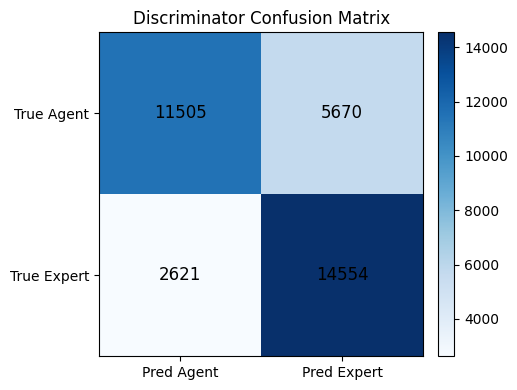

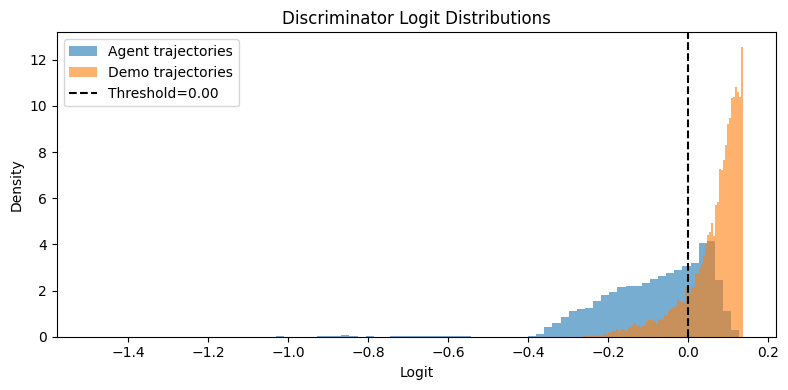

((-0.5, 0.5), (-0.5, 0.5))
Shared axis limits for trajectory plots: ((-0.5, 0.5), (-0.5, 0.5))
TN_agent_as_agent: 11505 total, showing 20


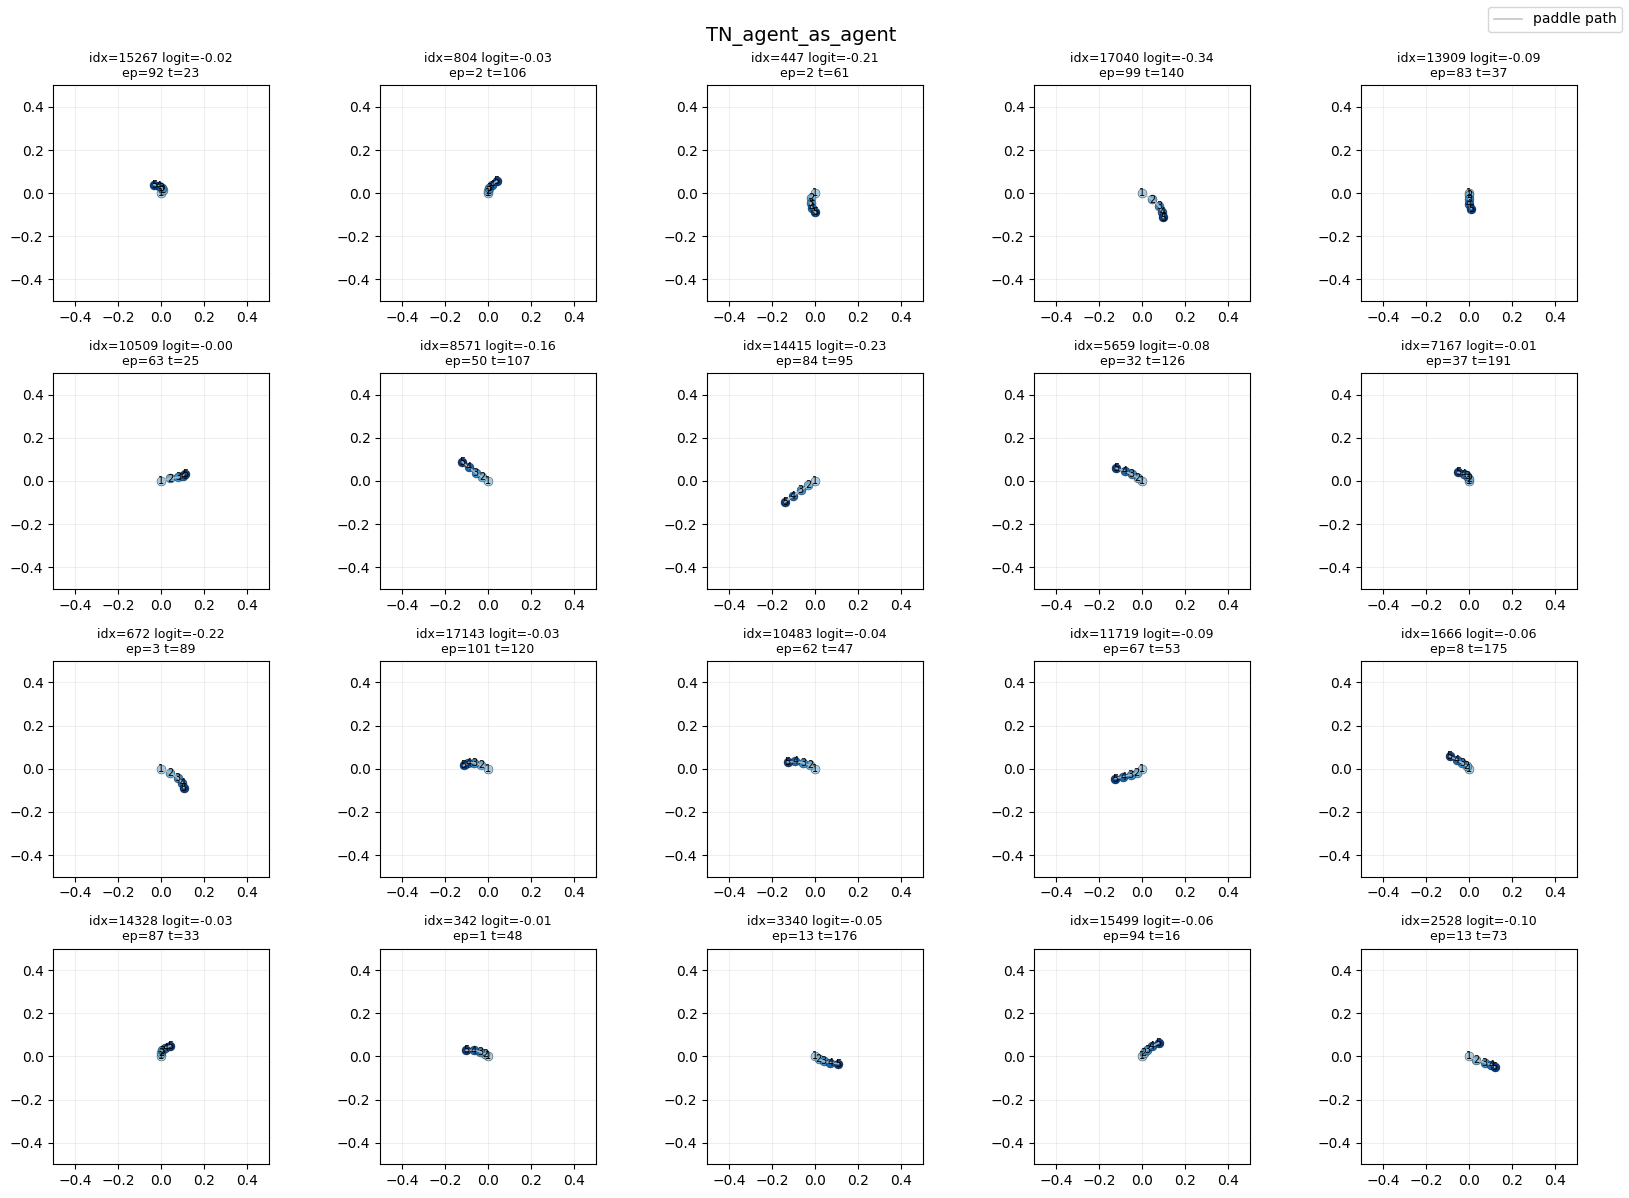

FP_agent_as_expert: 5670 total, showing 20


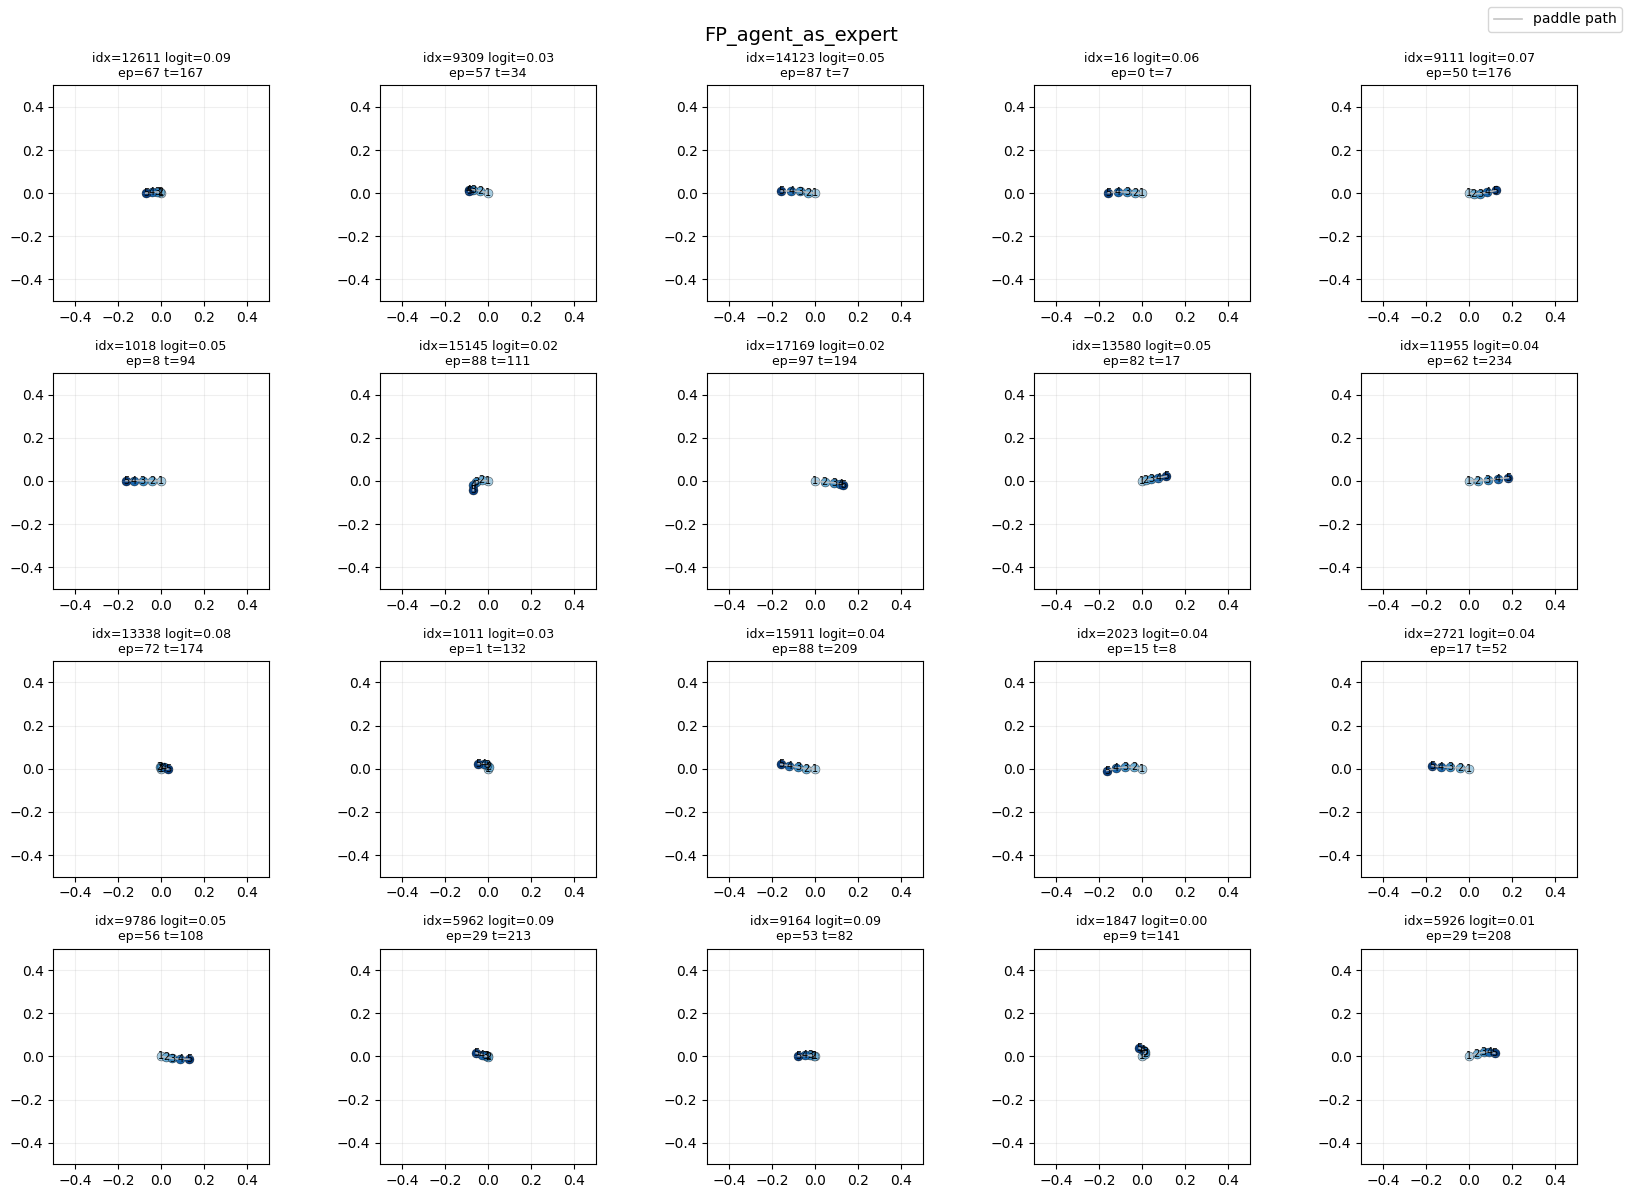

TP_demo_as_expert: 14554 total, showing 20


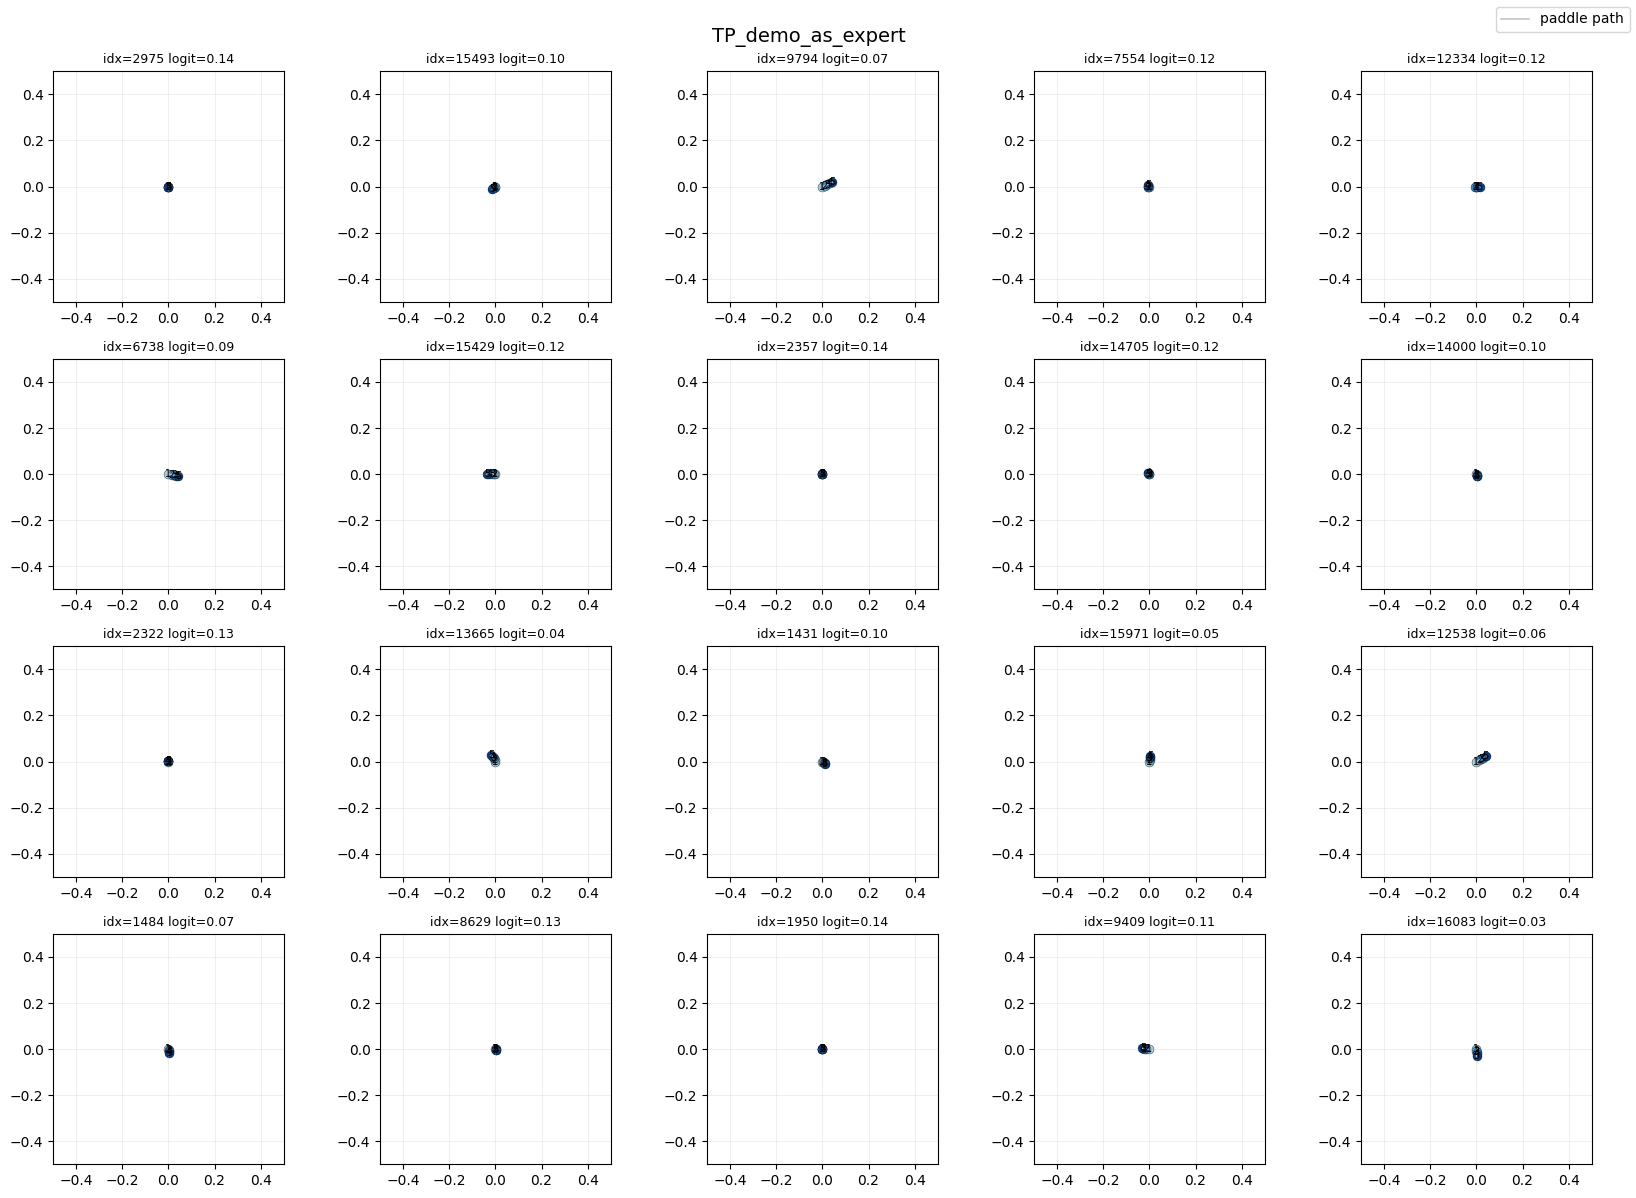

FN_demo_as_agent: 2621 total, showing 20


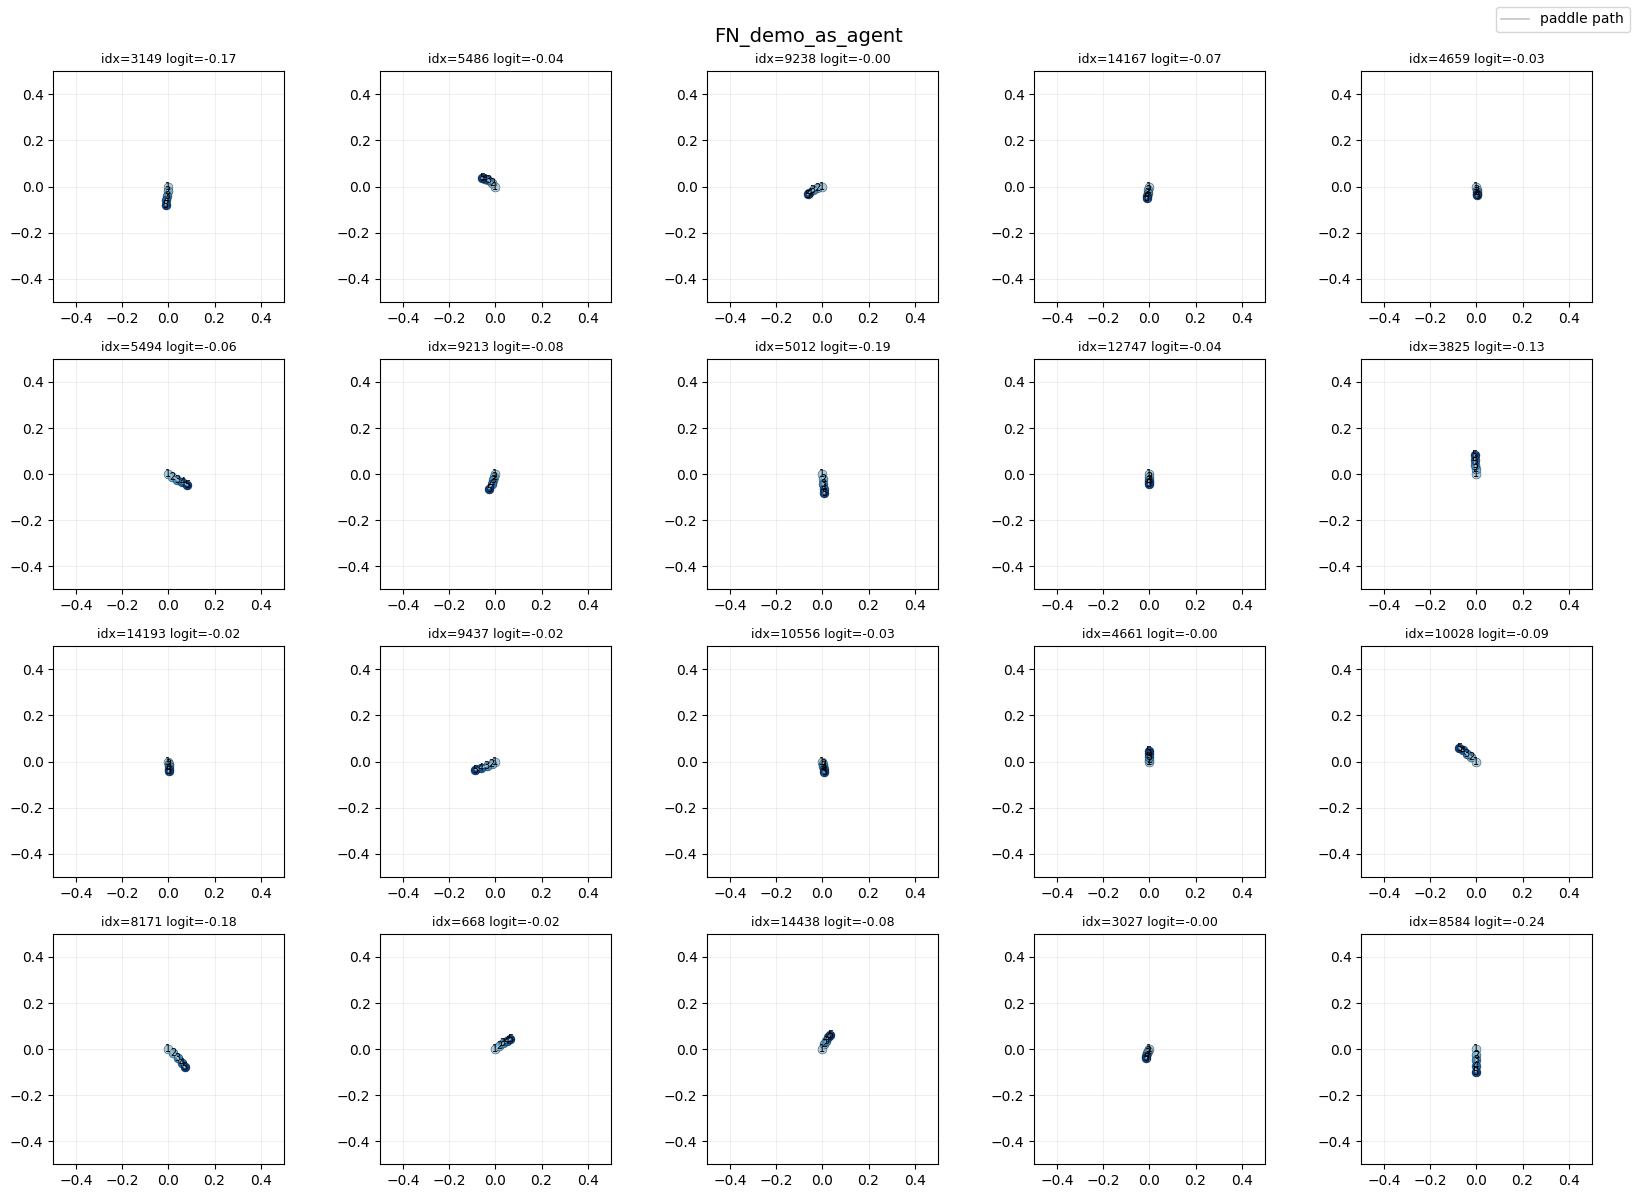

In [36]:
plot_confusion_matrix(confusion)
plot_logit_distributions(agent_logits, demo_logits, threshold=classification_threshold)

shared_axis_limits = compute_shared_axis_limits(
    agent_records=agent_records,
    demo_position_windows=demo_position_windows,
)
print(shared_axis_limits)
print("Shared axis limits for trajectory plots:", shared_axis_limits)

temp_seed = np.random.seed()


plot_category_samples(
    category_name="TN_agent_as_agent",
    source="agent",
    indices=categories["TN_agent_as_agent"],
    logits=agent_logits,
    sample_k=samples_per_category_plot,
    agent_records=agent_records,
    demo_position_windows=demo_position_windows,
    axis_limits=shared_axis_limits,
    seed=temp_seed,
)

plot_category_samples(
    category_name="FP_agent_as_expert",
    source="agent",
    indices=categories["FP_agent_as_expert"],
    logits=agent_logits,
    sample_k=samples_per_category_plot,
    agent_records=agent_records,
    demo_position_windows=demo_position_windows,
    axis_limits=shared_axis_limits,
    seed=temp_seed,
)

plot_category_samples(
    category_name="TP_demo_as_expert",
    source="demo",
    indices=categories["TP_demo_as_expert"],
    logits=demo_logits,
    sample_k=samples_per_category_plot,
    agent_records=agent_records,
    demo_position_windows=demo_position_windows,
    axis_limits=shared_axis_limits,
    seed=temp_seed,
)

plot_category_samples(
    category_name="FN_demo_as_agent",
    source="demo",
    indices=categories["FN_demo_as_agent"],
    logits=demo_logits,
    sample_k=samples_per_category_plot,
    agent_records=agent_records,
    demo_position_windows=demo_position_windows,
    axis_limits=shared_axis_limits,
    seed=temp_seed,
)

In [30]:
def show_hard_examples(agent_records, agent_logits, demo_logits, top_k=20, threshold=0.0):
    agent_margin = np.abs(agent_logits - threshold)
    demo_margin = np.abs(demo_logits - threshold)

    hard_agent_idx = np.argsort(agent_margin)[:top_k]
    hard_demo_idx = np.argsort(demo_margin)[:top_k]

    print(f"Hard agent examples (closest logits to {threshold}):")
    for i in hard_agent_idx:
        rec = agent_records[int(i)]
        pred = "expert" if agent_logits[int(i)] > threshold else "agent"
        print(
            f"  idx={int(i):6d} logit={agent_logits[int(i)]: .4f} pred={pred:>6s} "
            f"ep={rec['episode_id']:5d} t={rec['step_in_episode']:4d}"
        )

    print("\nHard demo examples (closest logits to threshold):")
    for i in hard_demo_idx:
        pred = "expert" if demo_logits[int(i)] > threshold else "agent"
        print(f"  idx={int(i):6d} logit={demo_logits[int(i)]: .4f} pred={pred:>6s}")


show_hard_examples(
    agent_records=agent_records,
    agent_logits=agent_logits,
    demo_logits=demo_logits,
    top_k=20,
    threshold=classification_threshold,
)

Hard agent examples (closest logits to 0.0):
  idx= 11680 logit=-0.0000 pred= agent ep=   66 t=  90
  idx= 12257 logit= 0.0000 pred=expert ep=   74 t=   9
  idx=  4267 logit= 0.0000 pred=expert ep=   28 t=   5
  idx=  5981 logit= 0.0000 pred=expert ep=   41 t=   5
  idx=  7224 logit=-0.0000 pred= agent ep=   44 t= 112
  idx= 16263 logit= 0.0000 pred=expert ep=   99 t=  41
  idx=  7690 logit= 0.0000 pred=expert ep=   44 t= 171
  idx=  1608 logit=-0.0000 pred= agent ep=    6 t= 206
  idx=  6516 logit= 0.0000 pred=expert ep=   41 t=  73
  idx= 16135 logit= 0.0001 pred=expert ep=   94 t=  97
  idx= 12652 logit= 0.0001 pred=expert ep=   70 t= 132
  idx= 15158 logit= 0.0001 pred=expert ep=   92 t=   9
  idx=  2915 logit= 0.0001 pred=expert ep=   11 t= 122
  idx=  3789 logit= 0.0001 pred=expert ep=   23 t=  67
  idx=    80 logit= 0.0001 pred=expert ep=    0 t=  15
  idx=    47 logit= 0.0001 pred=expert ep=    7 t=  10
  idx= 13372 logit= 0.0002 pred=expert ep=   76 t= 116
  idx=  6006 logit= 

In [ ]:
# Optional cleanup (run when finished)
# envs.close()